In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:

# Cargar la base de datos del SNIIM
df_precios = pd.read_csv('/content/serie_tiempo_precio_mayoreo.csv')

df_precios.head()


,anio,mes,Precio_Promedio_kg
0,2001,1,13.18
1,2001,2,13.02
2,2001,3,13.03
3,2001,4,13.35
4,2001,5,14.98


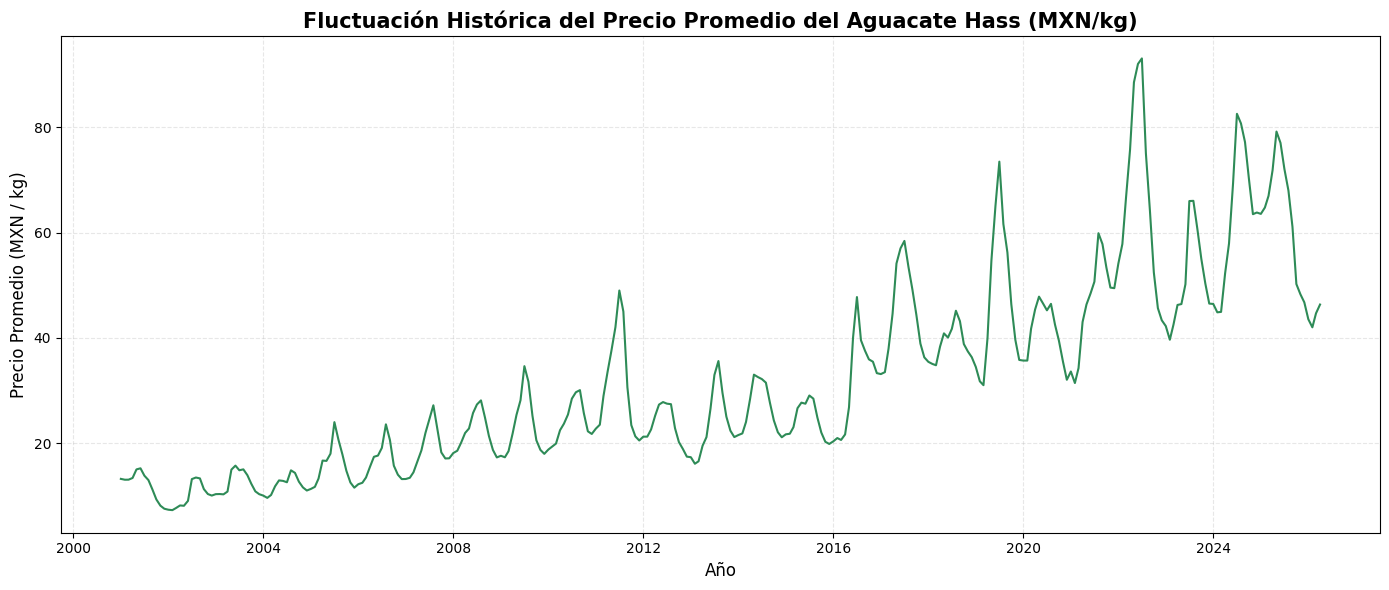

In [ ]:
#Creamos una copia por seguridad
df_temp = df_precios.copy()

# 2. Renombramos las columnas a lo que pandas espera: 'year', 'month' y 'day'
df_temp = df_temp.rename(columns={'anio': 'year', 'mes': 'month'})
df_temp['day'] = 1

# 3. Ahora sí, convertimos a formato fecha
df_temp['Fecha'] = pd.to_datetime(df_temp[['year', 'month', 'day']])

# 4. Establecemos la fecha como índice
df_temp.set_index('Fecha', inplace=True)

# 5. Visualización
plt.figure(figsize=(14, 6))
plt.plot(df_temp.index, df_temp['Precio_Promedio_kg'], color='#2E8B57', linewidth=1.5)

plt.title('Fluctuación Histórica del Precio Promedio del Aguacate Hass (MXN/kg)', fontsize=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Precio Promedio (MXN / kg)', fontsize=12)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Analizamos el precio precio promedio de la caja de 9 kg en la central de abasto de cdmx

In [3]:
df_c9 = pd.read_csv('/content/precios_cdmx_caja_9kg_2018_2026.csv')

#Se cometió un error al nombrar la columna la primera vez, pero los datos son los correctos
df_c9 = df_c9.rename(columns={'Precio_Promedio_kg': 'Precio Promedio Caja 9kg'})

df_c9.head()

,anio,mes,Precio Promedio Caja 9kg
0,2018,1,322.73
1,2018,2,333.68
2,2018,3,315.26
3,2018,4,361.90
4,2018,5,408.18


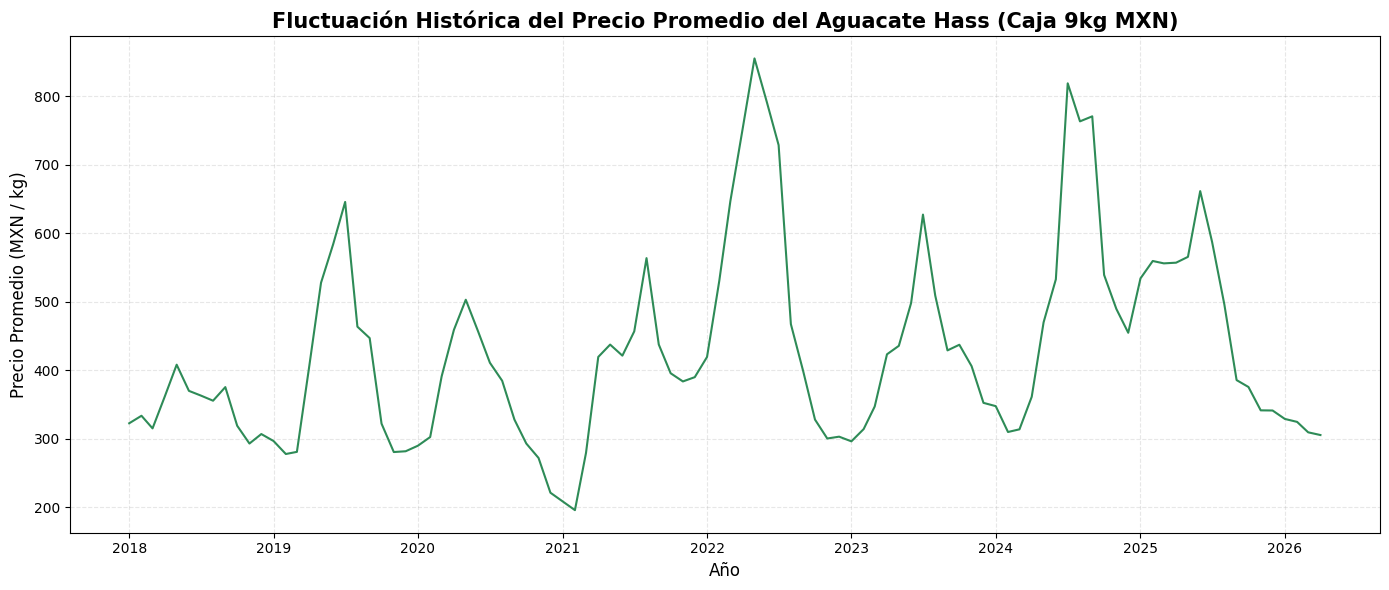

In [5]:
#Creamos una copia por seguridad
df_temp = df_c9.copy()

# 2. Renombramos las columnas a lo que pandas espera: 'year', 'month' y 'day'
df_temp = df_temp.rename(columns={'anio': 'year', 'mes': 'month'})
df_temp['day'] = 1

# 3. Ahora sí, convertimos a formato fecha
df_temp['Fecha'] = pd.to_datetime(df_temp[['year', 'month', 'day']])

# 4. Establecemos la fecha como índice
df_temp.set_index('Fecha', inplace=True)

# 5. Visualización
plt.figure(figsize=(14, 6))
plt.plot(df_temp.index, df_temp['Precio Promedio Caja 9kg'], color='#2E8B57', linewidth=1.5)

plt.title('Fluctuación Histórica del Precio Promedio del Aguacate Hass (Caja 9kg MXN)', fontsize=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Precio Promedio (MXN / kg)', fontsize=12)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Analizamos la estacionalidad de la serie de tiempo

In [19]:
df = df_temp[df_temp['year'] < 2026]
df = df['Precio Promedio Caja 9kg']
df.tail()

,Precio Promedio Caja 9kg
Fecha,
2025-08-01,496.19
2025-09-01,385.71
2025-10-01,375.65
2025-11-01,341.58
2025-12-01,341.36


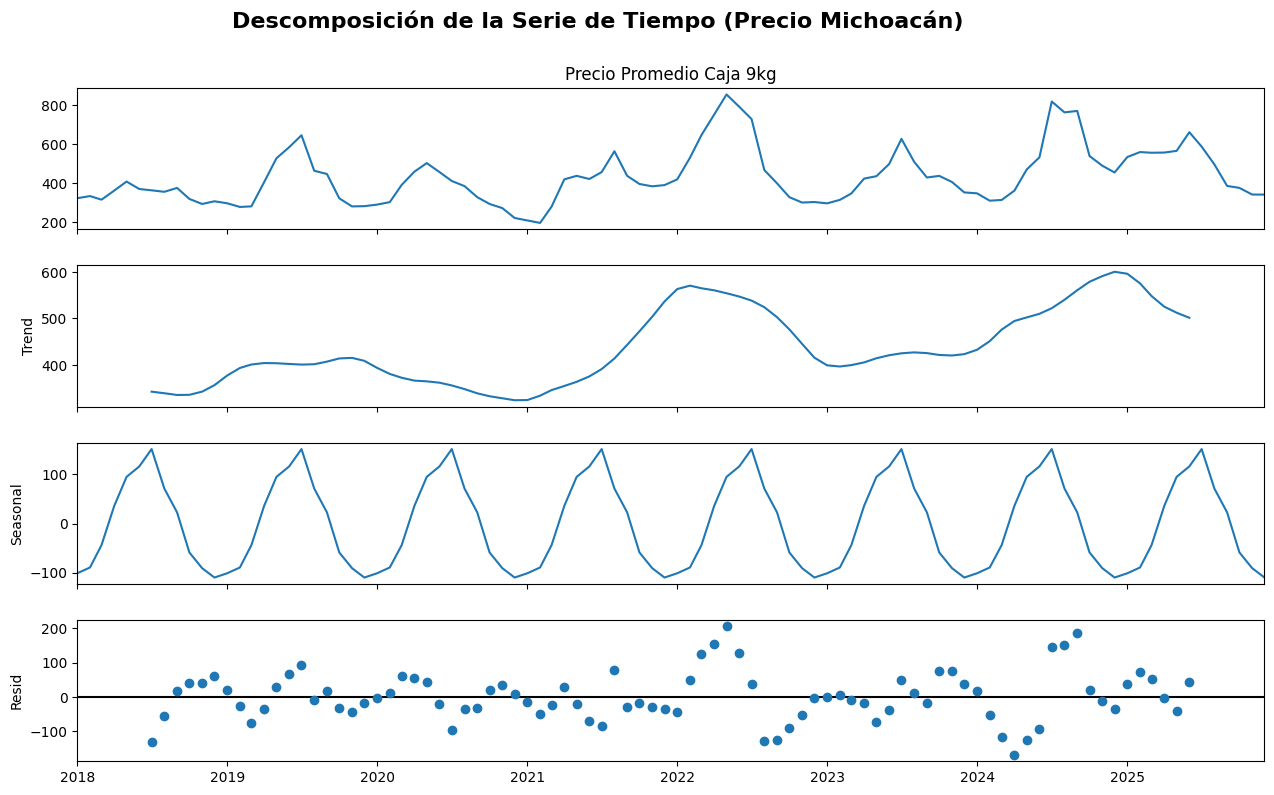

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

descomposicion = seasonal_decompose(df, model='additive', period=12)

# 2. Graficar los 3 componentes
fig = descomposicion.plot()
fig.set_size_inches(14, 8)
plt.suptitle('Descomposición de la Serie de Tiempo (Precio Michoacán)', fontsize=16, fontweight='bold', y=1.02)
plt.show()

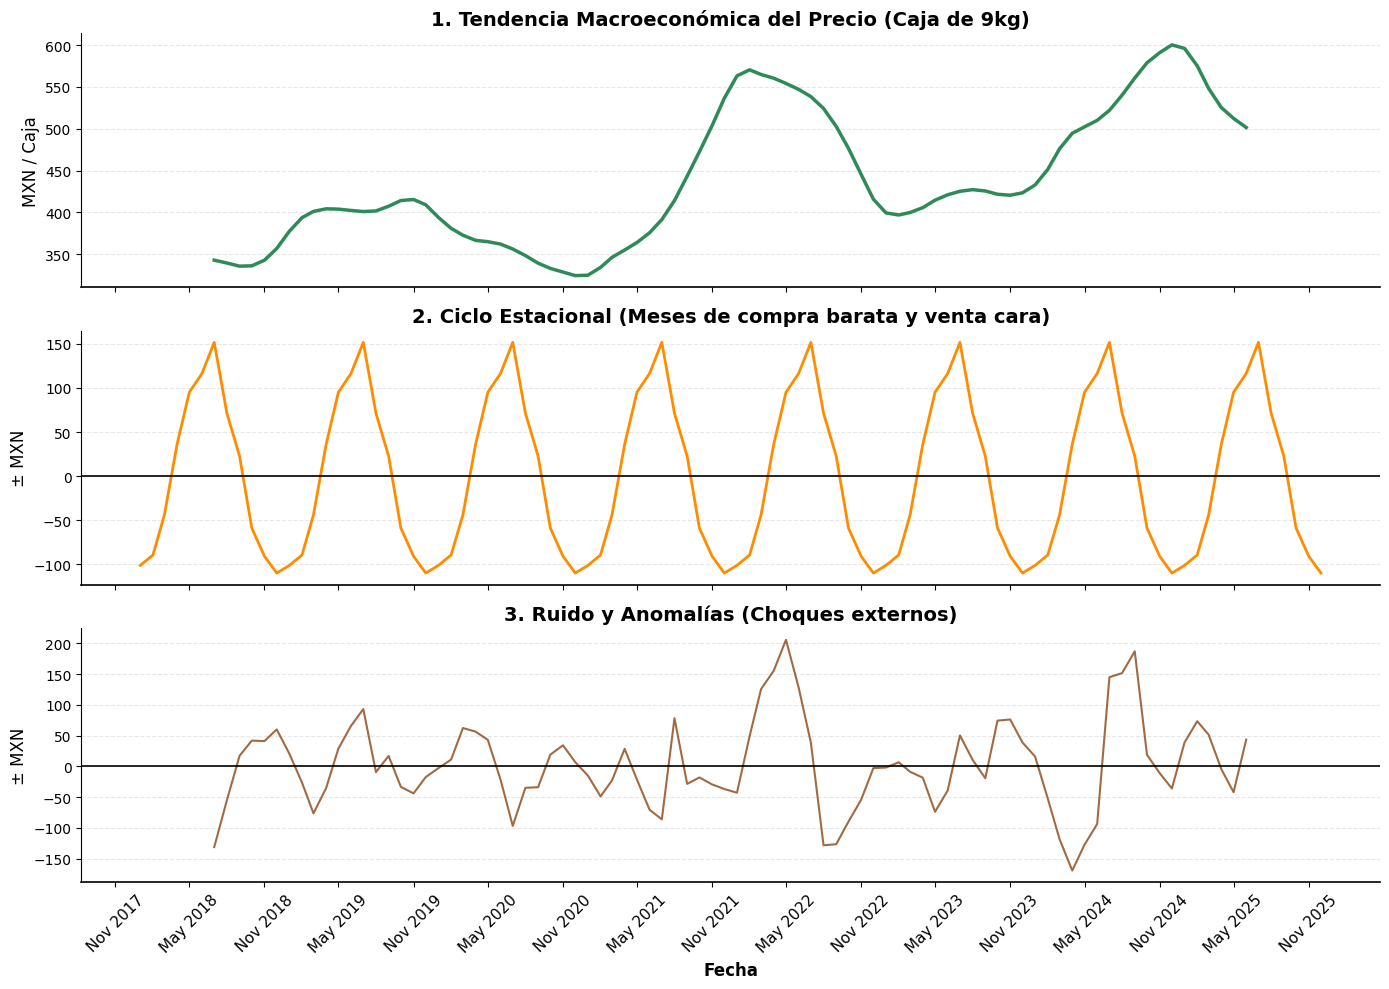

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose

descomposicion = seasonal_decompose(df, model='additive', period=12)

# 3. Configurar el lienzo
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Gráfica 1: Tendencia
ax1.plot(descomposicion.trend.index, descomposicion.trend, color='#2E8B57', linewidth=2.5)
ax1.set_title('1. Tendencia Macroeconómica del Precio (Caja de 9kg)', fontsize=14, fontweight='bold')
ax1.set_ylabel('MXN / Caja', fontsize=12)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Gráfica 2: Estacionalidad
ax2.plot(descomposicion.seasonal.index, descomposicion.seasonal, color='#FF8C00', linewidth=2)
ax2.set_title('2. Ciclo Estacional (Meses de compra barata y venta cara)', fontsize=14, fontweight='bold')
ax2.set_ylabel('± MXN', fontsize=12)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.axhline(0, color='black', linewidth=1.2)

# Gráfica 3: Ruido/Anomalías
ax3.plot(descomposicion.resid.index, descomposicion.resid, color='#8B4513', linewidth=1.5, alpha=0.8)
ax3.set_title('3. Ruido y Anomalías (Choques externos)', fontsize=14, fontweight='bold')
ax3.set_ylabel('± MXN', fontsize=12)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.axhline(0, color='black', linewidth=1.2)

# 4. Formateo estricto del Eje X para el rango 2018-2025
for ax in [ax1, ax2, ax3]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.spines['bottom'].set_color('black')

# Forzar marcas cada 6 meses (interval=6) para una lectura limpia
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45, fontsize=11)
plt.xlabel('Fecha', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Prueba de Estacionariedad de Dickey-Fuller Aumentada

In [26]:
df.head()

,Precio Promedio Caja 9kg
Fecha,
2018-01-01,322.73
2018-02-01,333.68
2018-03-01,315.26
2018-04-01,361.90
2018-05-01,408.18


In [27]:
from statsmodels.tsa.stattools import adfuller

print("--- Prueba de Estacionariedad: Dickey-Fuller Aumentada ---")
# Evaluamos la serie limpia que acabamos de crear
resultado_adf = adfuller(df)

print(f"Estadístico ADF: {resultado_adf[0]:.4f}")
print(f"p-value:         {resultado_adf[1]:.8f}")
print("----------------------------------------------------------")
print("Valores Críticos:")
for key, value in resultado_adf[4].items():
    print(f"  {key}: {value:.4f}")

if resultado_adf[1] < 0.05:
    print("\n[CONCLUSIÓN]: El p-value es MENOR a 0.05. La serie ES ESTACIONARIA (d=0 para ARIMA).")
else:
    print("\n[CONCLUSIÓN]: El p-value es MAYOR a 0.05. La serie NO ES ESTACIONARIA (Requiere diferenciación, d>=1 para ARIMA).")

--- Prueba de Estacionariedad: Dickey-Fuller Aumentada ---
Estadístico ADF: -5.1997
p-value:         0.00000880
----------------------------------------------------------
Valores Críticos:
  1%: -3.5027
  5%: -2.8932
  10%: -2.5836

[CONCLUSIÓN]: El p-value es MENOR a 0.05. La serie ES ESTACIONARIA (d=0 para ARIMA).


Como la prueba de Dickey-Fuller confirmó que la serie es estacionaria ($d=0$), el modelo $ARIMA(p, d, q)$ se simplifica algebraicamente a un modelo $ARMA(p, q)$. La ecuación fundamental que el algoritmo intentará resolver para proyectar el costo en un momento futuro ($Y_t$) es:$$Y_t = c + \phi_1 Y_{t-1} + \dots + \phi_p Y_{t-p} + \theta_1 \epsilon_{t-1} + \dots + \theta_q \epsilon_{t-q} + \epsilon_t$$Donde $p$ representa los "rezagos" (cómo el precio de los meses pasados afecta al actual) y $q$ representa los errores o "shocks" pasados del mercado.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

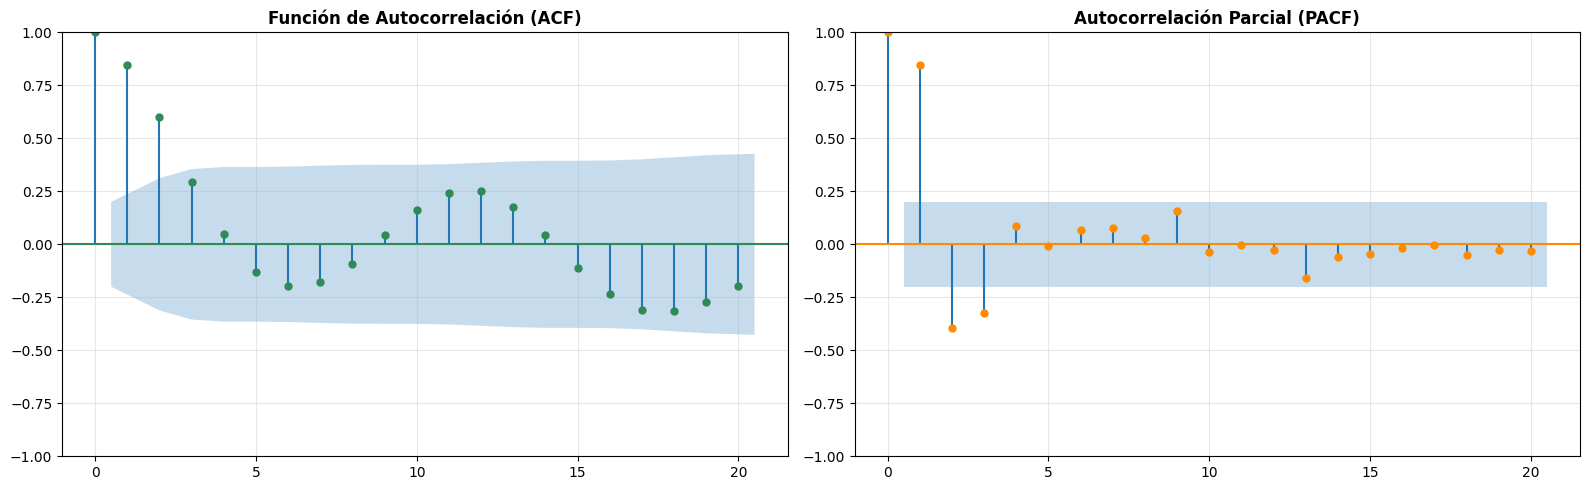

In [30]:
# ---------------------------------------------------------
# 1. IDENTIFICACIÓN DE PARÁMETROS (ACF y PACF)
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# ACF (Ayuda a determinar el parámetro 'q')
plot_acf(df, lags=20, ax=ax1, color='#2E8B57')
ax1.set_title('Función de Autocorrelación (ACF)', fontweight='bold')
ax1.grid(alpha=0.3)

# PACF (Ayuda a determinar el parámetro 'p')
plot_pacf(df, lags=20, ax=ax2, color='#FF8C00', method='ywm')
ax2.set_title('Autocorrelación Parcial (PACF)', fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

El manual estadístico dicta que:

Si la PACF tiene un corte abrupto (en 3) y la ACF tiene un decaimiento gradual, estamos ante un modelo puramente Autorregresivo (AR).

Esto significa que los "shocks" pasados (el parámetro $q$) no son necesarios para explicar el fenómeno, porque los 3 meses de rezago ($p$) ya contienen toda esa información.

In [31]:
# ---------------------------------------------------------
# 2. ENTRENAMIENTO DEL MODELO ARIMA Y PRONÓSTICO
# ---------------------------------------------------------
# Como la serie es estacionaria, d = 0.
p = 3
d = 0
q = 0

modelo_arima = ARIMA(df, order=(p, d, q))
resultados_arima = modelo_arima.fit()

# Imprimir el resumen estadístico para el reporte
print(resultados_arima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                  SARIMAX Results                                   
Dep. Variable:     Precio Promedio Caja 9kg   No. Observations:                   96
Model:                       ARIMA(3, 0, 0)   Log Likelihood                -537.290
Date:                      Mon, 01 Jun 2026   AIC                           1084.581
Time:                              08:57:42   BIC                           1097.402
Sample:                          01-01-2018   HQIC                          1089.763
                               - 12-01-2025                                         
Covariance Type:                        opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        433.0270     30.246     14.317      0.000     373.746     492.308
ar.L1          1.0549      0.111      9.469      0.000       0.837       1.273
ar.L

In [34]:
# ---------------------------------------------------------
# 2. ENTRENAMIENTO DEL MODELO ARIMA Y PRONÓSTICO
# ---------------------------------------------------------
# Como la serie es estacionaria, d = 0.
p = 1
d = 0
q = 1

modelo_arima = ARIMA(df, order=(p, d, q))
resultados_arima = modelo_arima.fit()

# Imprimir el resumen estadístico para el reporte
print(resultados_arima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                  SARIMAX Results                                   
Dep. Variable:     Precio Promedio Caja 9kg   No. Observations:                   96
Model:                       ARIMA(1, 0, 1)   Log Likelihood                -546.531
Date:                      Mon, 01 Jun 2026   AIC                           1101.062
Time:                              09:07:03   BIC                           1111.319
Sample:                          01-01-2018   HQIC                          1105.208
                               - 12-01-2025                                         
Covariance Type:                        opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        432.9398     58.783      7.365      0.000     317.727     548.152
ar.L1          0.7870      0.073     10.719      0.000       0.643       0.931
ma.L

In [35]:
p = 1
d = 0
q = 2

modelo_arima = ARIMA(df, order=(p, d, q))
resultados_arima = modelo_arima.fit()

# Imprimir el resumen estadístico para el reporte
print(resultados_arima.summary())

                                  SARIMAX Results                                   
Dep. Variable:     Precio Promedio Caja 9kg   No. Observations:                   96
Model:                       ARIMA(1, 0, 2)   Log Likelihood                -539.731
Date:                      Mon, 01 Jun 2026   AIC                           1089.461
Time:                              09:09:15   BIC                           1102.283
Sample:                          01-01-2018   HQIC                          1094.644
                               - 12-01-2025                                         
Covariance Type:                        opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        427.4422     49.969      8.554      0.000     329.504     525.381
ar.L1          0.6750      0.092      7.312      0.000       0.494       0.856
ma.L

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [44]:
df_2026 = df_temp['Precio Promedio Caja 9kg']

df_2026.tail()

,Precio Promedio Caja 9kg
Fecha,
2025-12-01,341.36
2026-01-01,329.05
2026-02-01,324.74
2026-03-01,309.52
2026-04-01,305.56


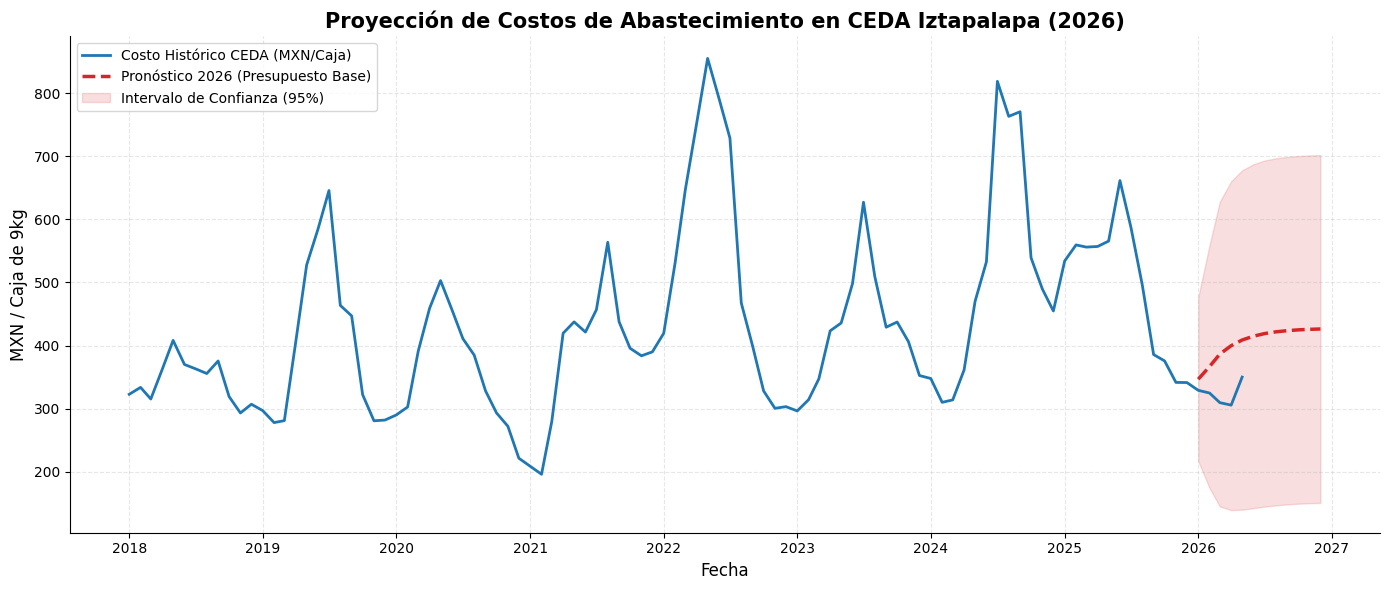

In [55]:


# ---------------------------------------------------------
# 3. PROYECCIÓN HACIA 2026 (12 meses a futuro)
# ---------------------------------------------------------
pasos_futuro = 12
pronostico = resultados_arima.get_forecast(steps=pasos_futuro)
prediccion_media = pronostico.predicted_mean
intervalo_confianza = pronostico.conf_int(alpha=0.05) # 95% de confianza

# Unir el índice temporal original con las fechas futuras
fechas_futuras = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=pasos_futuro, freq='MS')
prediccion_media.index = fechas_futuras
intervalo_confianza.index = fechas_futuras

# ---------------------------------------------------------
# 4. VISUALIZACIÓN EJECUTIVA DEL PRONÓSTICO
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))

# Graficar la historia real (2018-2025)
plt.plot(df_2026.index, df_2026.values, label='Costo Histórico CEDA (MXN/Caja)', color='#1f77b4', linewidth=2)

# Graficar la predicción (2026)
plt.plot(prediccion_media.index, prediccion_media.values, label='Pronóstico 2026 (Presupuesto Base)', color='#d62728', linewidth=2.5, linestyle='--')

# Graficar el intervalo de confianza (Riesgo financiero)
plt.fill_between(intervalo_confianza.index,
                 intervalo_confianza.iloc[:, 0],
                 intervalo_confianza.iloc[:, 1],
                 color='#d62728', alpha=0.15, label='Intervalo de Confianza (95%)')

plt.title('Proyección de Costos de Abastecimiento en CEDA Iztapalapa (2026)', fontsize=15, fontweight='bold')
plt.ylabel('MXN / Caja de 9kg', fontsize=12)
plt.xlabel('Fecha', fontsize=12)

# Limpieza visual y formato
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.legend(loc='upper left')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

SARIMA

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [40]:
# ---------------------------------------------------------
#  ENTRENAMIENTO DEL MODELO SARIMA
# ---------------------------------------------------------
# Parámetros base (los que ganaron en tu prueba anterior)
p, d, q = 1, 0, 2

# Parámetros Estacionales (P, D, Q, s) -> s=12 indica meses del año
P, D, Q, s = 1, 0, 1, 12

# Instanciar y entrenar el modelo SARIMAX
modelo_sarima = SARIMAX(df,
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, s),
                        enforce_stationarity=False,
                        enforce_invertibility=False)

resultados_sarima = modelo_sarima.fit(disp=False)

# Imprimir resumen para verificar si el AIC mejoró
print("--- Resumen del Modelo SARIMA ---")
print(resultados_sarima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


--- Resumen del Modelo SARIMA ---
                                      SARIMAX Results                                       
Dep. Variable:             Precio Promedio Caja 9kg   No. Observations:                   96
Model:             SARIMAX(1, 0, 2)x(1, 0, [1], 12)   Log Likelihood                -459.415
Date:                              Mon, 01 Jun 2026   AIC                            930.829
Time:                                      09:31:24   BIC                            945.196
Sample:                                  01-01-2018   HQIC                           936.593
                                       - 12-01-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6599      0.103      6.385      0.000       0.4

Acabó mayo y se tienen nuevos datos

In [45]:
df_2026.loc['2026-05-01'] = 350

df_2026.tail()

,Precio Promedio Caja 9kg
Fecha,
2026-01-01,329.05
2026-02-01,324.74
2026-03-01,309.52
2026-04-01,305.56
2026-05-01,350.00


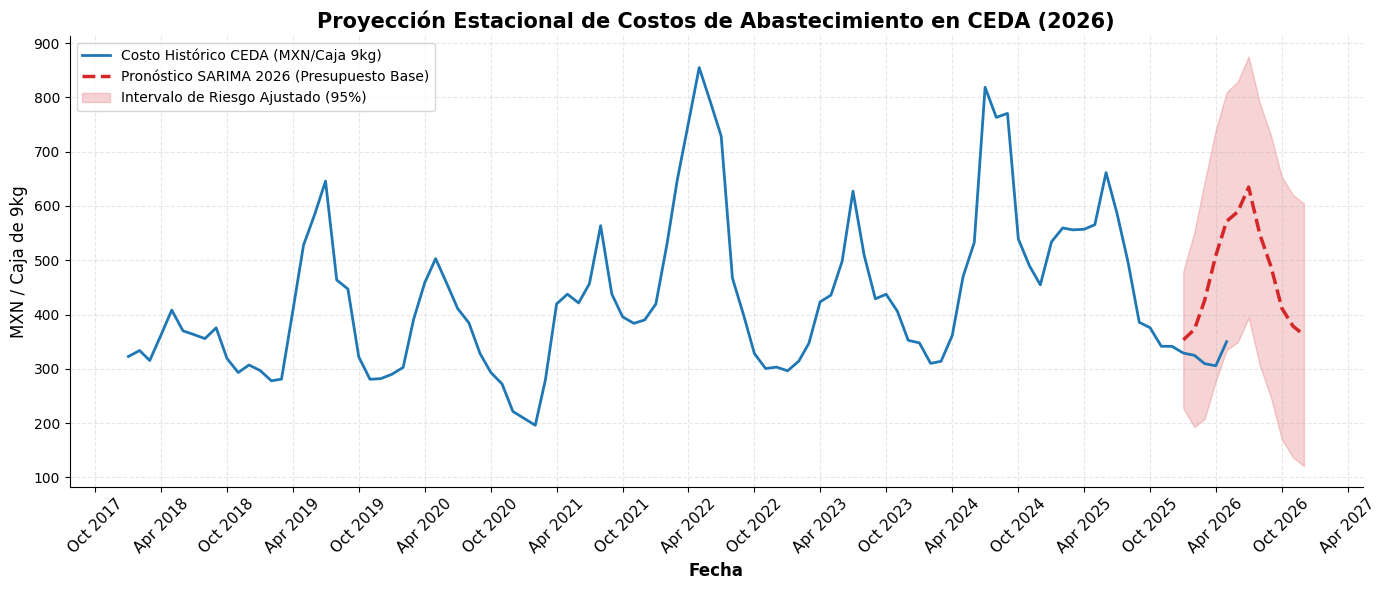

In [54]:
# ---------------------------------------------------------
# 2. PROYECCIÓN HACIA 2026 (12 meses a futuro)
# ---------------------------------------------------------
pasos_futuro = 12
pronostico_sarima = resultados_sarima.get_forecast(steps=pasos_futuro)
prediccion_media = pronostico_sarima.predicted_mean
intervalo_confianza = pronostico_sarima.conf_int(alpha=0.05) # 95% de confianza

# Unir el índice temporal original con las fechas futuras
fechas_futuras = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=pasos_futuro, freq='MS')
prediccion_media.index = fechas_futuras
intervalo_confianza.index = fechas_futuras

# ---------------------------------------------------------
# 3. VISUALIZACIÓN EJECUTIVA DEL PRONÓSTICO SARIMA
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))

# Graficar la historia real (2018-2025)
plt.plot(df_2026.index, df_2026.values, label='Costo Histórico CEDA (MXN/Caja 9kg)', color='#1f77b4', linewidth=2)

# Graficar la predicción SARIMA (2026)
plt.plot(prediccion_media.index, prediccion_media.values, label='Pronóstico SARIMA 2026 (Presupuesto Base)', color='#d62728', linewidth=2.5, linestyle='--')

# Graficar el nuevo intervalo de confianza ajustado
plt.fill_between(intervalo_confianza.index,
                 intervalo_confianza.iloc[:, 0],
                 intervalo_confianza.iloc[:, 1],
                 color='#d62728', alpha=0.2, label='Intervalo de Riesgo Ajustado (95%)')

plt.title('Proyección Estacional de Costos de Abastecimiento en CEDA (2026)', fontsize=15, fontweight='bold')
plt.ylabel('MXN / Caja de 9kg', fontsize=12)
plt.xlabel('Fecha', fontsize=12, fontweight='bold')

# Limpieza visual y formato de fechas
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45, fontsize=11)
plt.legend(loc='upper left')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()